In [23]:
from idlelib.debugger_r import restart_subprocess_debugger

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Activation, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from keras.utils import plot_model
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np


In [24]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [25]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

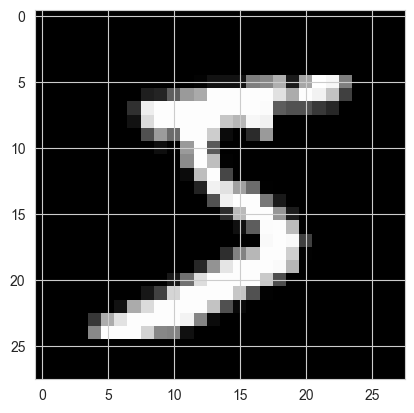

In [26]:
plt.imshow(x_train[0], cmap='gray')

In [27]:
y_train[0]

np.uint8(5)

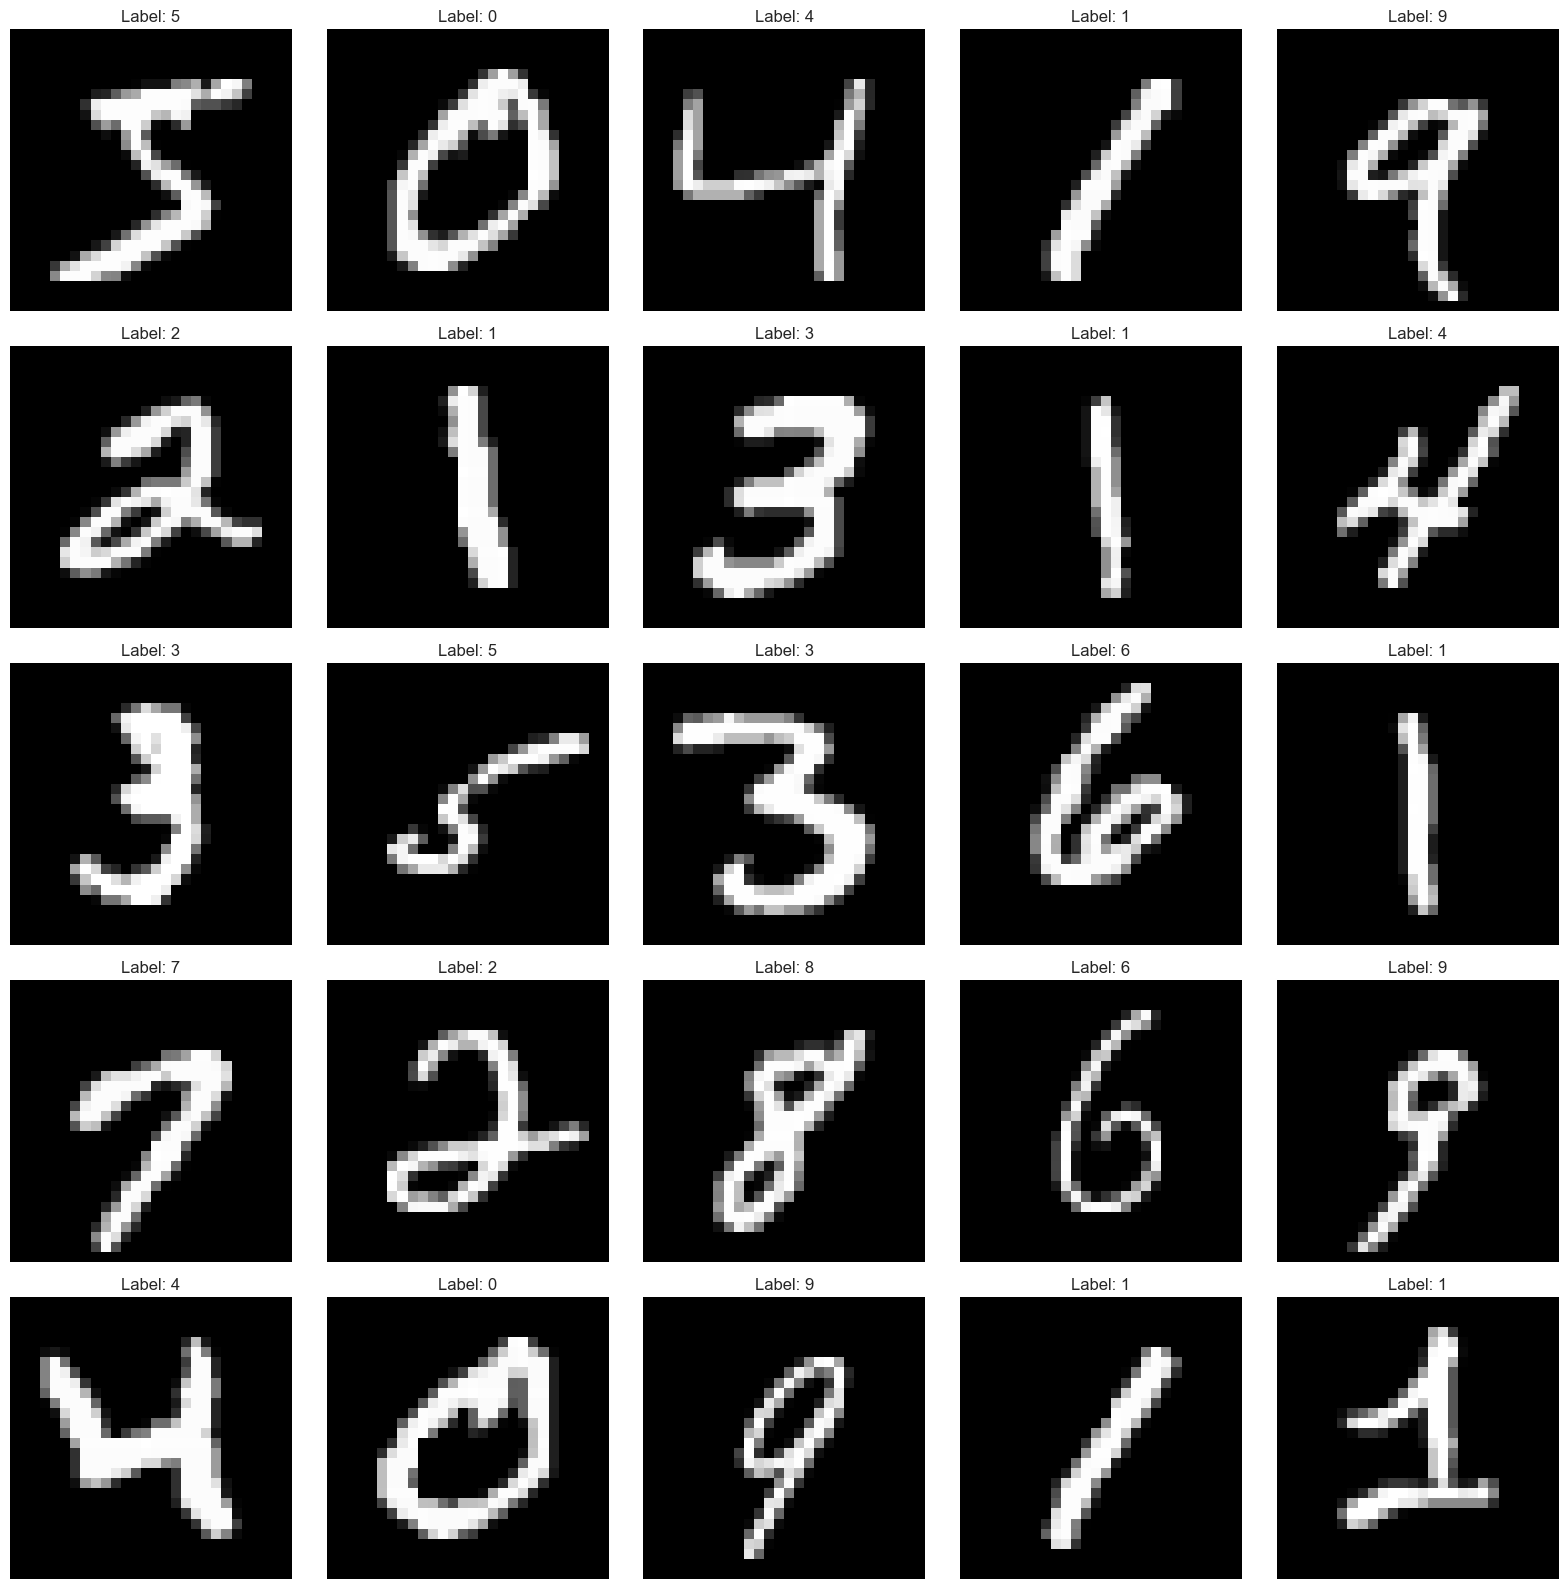

In [28]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

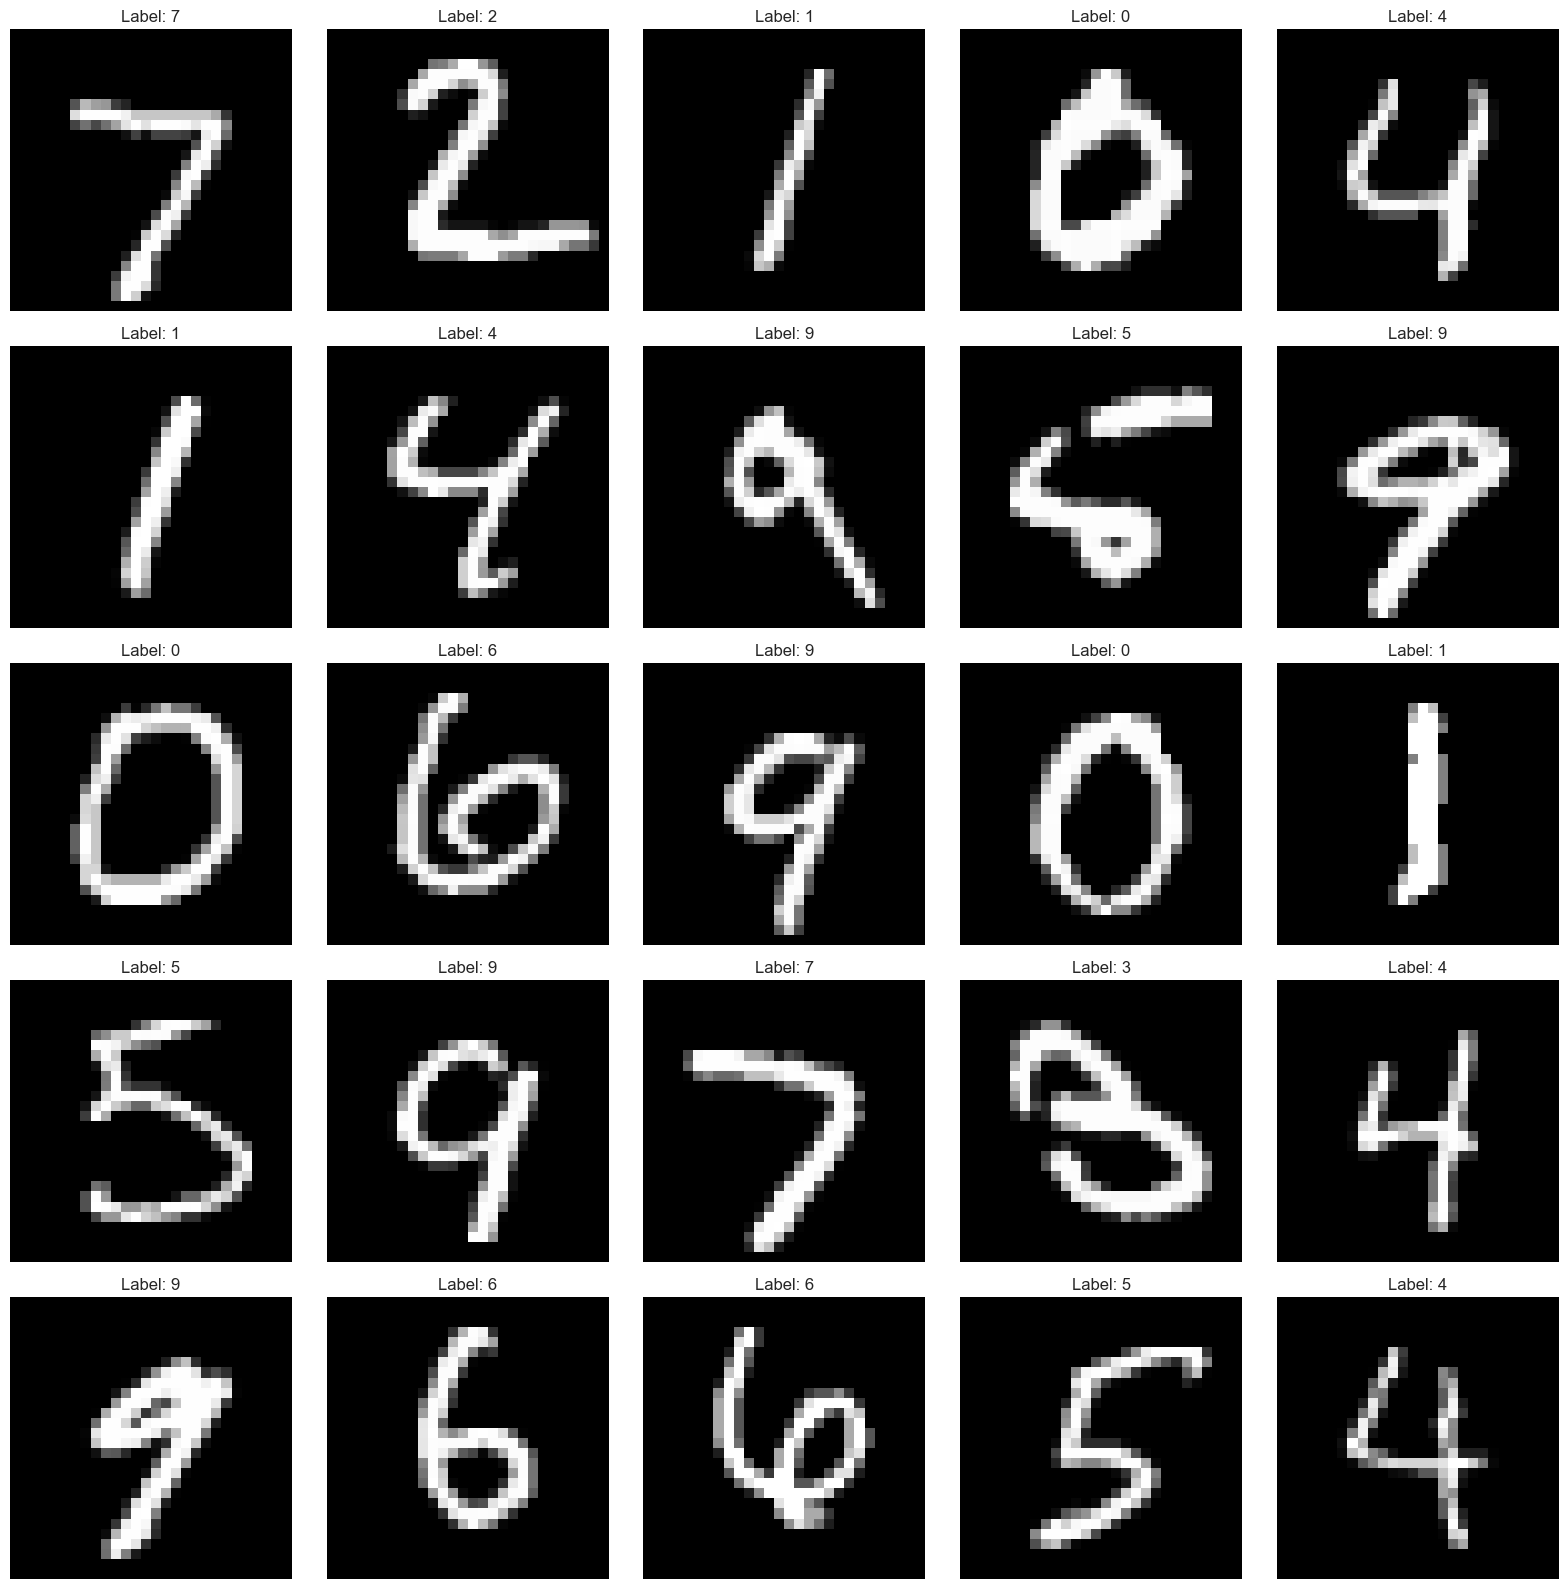

In [29]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
import seaborn as sns

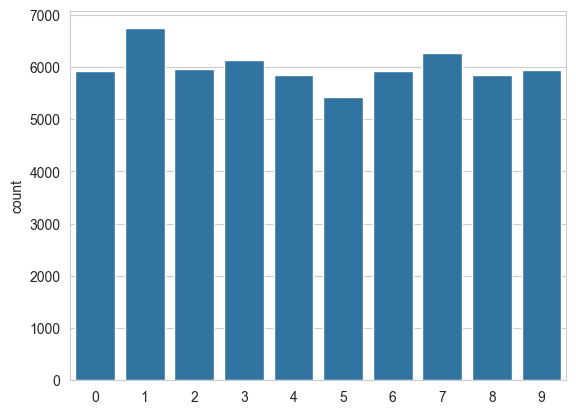

In [31]:
sns.countplot(x = y_train);

In [32]:
# Normalise
x_train = x_train/255
x_test = x_test/255

In [33]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [34]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [35]:
x_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [36]:
y_train.shape

(60000,)

In [42]:
from keras.utils import to_categorical

y_train_new = to_categorical(y_train)
y_test_new = to_categorical(y_test)
y_train_new.shape, y_test_new.shape

((60000, 10), (10000, 10))

### Build the model

In [43]:
model = Sequential()
model.add(Input(shape=(28,28,1)))

model.add(Conv2D(filters=16,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [44]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,426 (829.79 KB)

 Trainable params: 212,426 (829.79 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [46]:
model.fit(x_train, y_train_new, epochs=10, batch_size=10, verbose =2)

Epoch 1/10
6000/6000 - 31s - 5ms/step - accuracy: 0.9647 - loss: 0.1140
Epoch 2/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9862 - loss: 0.0440
Epoch 3/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9915 - loss: 0.0277
Epoch 4/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9932 - loss: 0.0206
Epoch 5/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9952 - loss: 0.0154
Epoch 6/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9958 - loss: 0.0127
Epoch 7/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9966 - loss: 0.0107
Epoch 8/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9970 - loss: 0.0089
Epoch 9/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9971 - loss: 0.0095
Epoch 10/10
6000/6000 - 29s - 5ms/step - accuracy: 0.9975 - loss: 0.0079


In [47]:
model.evaluate(x_test, y_test_new, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9884 - loss: 0.0625


[0.06248172000050545, 0.9883999824523926]

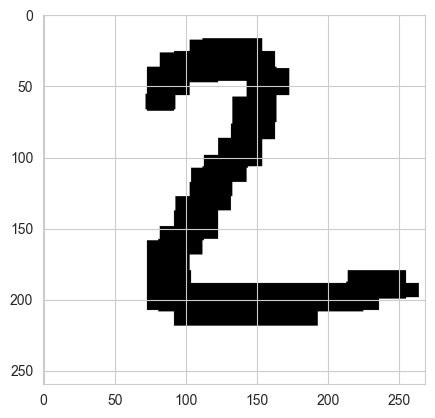

In [59]:
import cv2
test_img = cv2.imread(r"C:\Users\dai\PycharmProjects\NLP-CV\S12\images\new-char.png", 0)
inv_binary_img=test_img<120
plt.imshow(inv_binary_img,cmap='gray')

In [60]:
inv_binary_img = inv_binary_img.astype(np.uint8) * 255

In [61]:
inv_binary_img.shape

(260, 269)

In [62]:
inv_binary_img = cv2.resize(inv_binary_img, (28, 28))

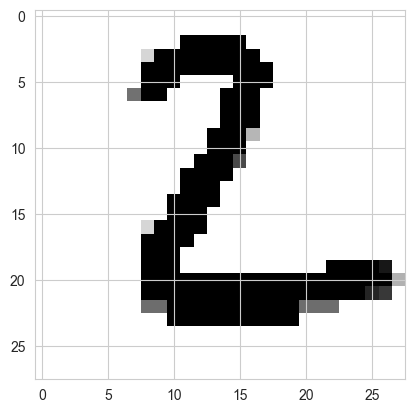

In [63]:
plt.imshow(inv_binary_img,cmap='gray')

In [64]:
img_tst = inv_binary_img.reshape(1,28,28)

In [65]:
result = np.argmax(model.predict(img_tst))
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


np.int64(2)